In [1]:
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Find the project root and model directory
project_root = Path.cwd().resolve()
for folder in [project_root, *project_root.parents]:
    if (folder / "models" / "phase1_outputs.pkl").exists():
        project_root = folder
        models_dir = folder / "models"
        break
else:
    raise FileNotFoundError("Could not locate the models directory.")

# Load Phase 1 (graph + raw data)
with open(models_dir / "phase1_outputs.pkl", "rb") as f:
    p1 = pickle.load(f)

G        = p1["G"]
df_full  = p1["df_full"]
df_edges = p1["df_edges"]
node_list = p1["node_list"]
node_idx  = p1["node_idx"]

# Load Phase 2 (embeddings + scores)
with open(models_dir / "phase2_outputs.pkl", "rb") as f:
    p2 = pickle.load(f)
    stability_std = p2.get("stability_std")
if stability_std is None:
    print("Warning: stability_std not in phase2_outputs.pkl — rerun the new save cell at the end of 02_phase2_gnn.ipynb first.")

gnn_importance  = p2["gnn_importance"]
gnn_sensitivity = p2["gnn_sensitivity"]   # cosine similarity 32x32
df_rank         = p2["df_rank"]

# Rebuild PyG data object (needed for perturbation sensitivity)
feature_cols = ["elevation_m", "catchment_area_km2", "num_catchment_basins"]
df_aligned   = df_full.set_index("tank_name").reindex(node_list)
X_raw        = df_aligned[feature_cols].fillna(0).values
scaler       = StandardScaler()
X_tensor     = torch.tensor(scaler.fit_transform(X_raw), dtype=torch.float)

edge_src   = [node_idx[r.source_tank] for _, r in df_edges.iterrows()]
edge_tgt   = [node_idx[r.target_tank] for _, r in df_edges.iterrows()]
edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
edge_attr  = torch.tensor(df_edges[["elev_diff_m","slope_m/m"]].values, dtype=torch.float)
pyg_data   = Data(x=X_tensor, edge_index=edge_index, edge_attr=edge_attr)

# Load trained model weights (NO retraining)
class CascadeGAT(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, heads=2):
        super().__init__()
        self.conv1 = GATConv(in_ch, hidden, heads=heads, dropout=0.2)
        self.conv2 = GATConv(hidden*heads, out_ch, heads=1, concat=False)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

model = CascadeGAT(in_ch=3, hidden=16, out_ch=8)
model.load_state_dict(torch.load(models_dir / "cascade_gat_weights.pth", weights_only=True))
model.eval()
print("Model loaded. No retraining needed.")

# Compute final combined score
gnn_norm = (df_rank["gnn_importance"] - df_rank["gnn_importance"].min()) /            (df_rank["gnn_importance"].max() - df_rank["gnn_importance"].min())

df_rank["final_score"] = (df_rank["importance_score"] + gnn_norm) / 2
df_rank = df_rank.sort_values("final_score", ascending=False)
df_rank["final_rank"] = range(1, len(df_rank) + 1)

print(df_rank[["tank","final_rank","final_score","downstream_reach"]].head(10).to_string())


Model loaded. No retraining needed.
                      tank  final_rank  final_score  downstream_reach
30        Nachchaduwa Wewa           1     0.666667                 0
17        Manakkulama Wewa           2     0.524970                 3
13       Periyakulama Wewa           3     0.438435                 4
2             Pansala Wewa           4     0.372347                 6
5          Ulankulama Wewa           5     0.345508                 5
0   Tawalanhalmillewa Wewa           6     0.324225                 7
27         Todamaduwa Wewa           7     0.303720                 1
4    Maha Ittikattiya Wewa           8     0.300398                 5
22       Wannanmaduwa Wewa           9     0.295145                 2
1        Settikulama  Wewa          10     0.289503                 7


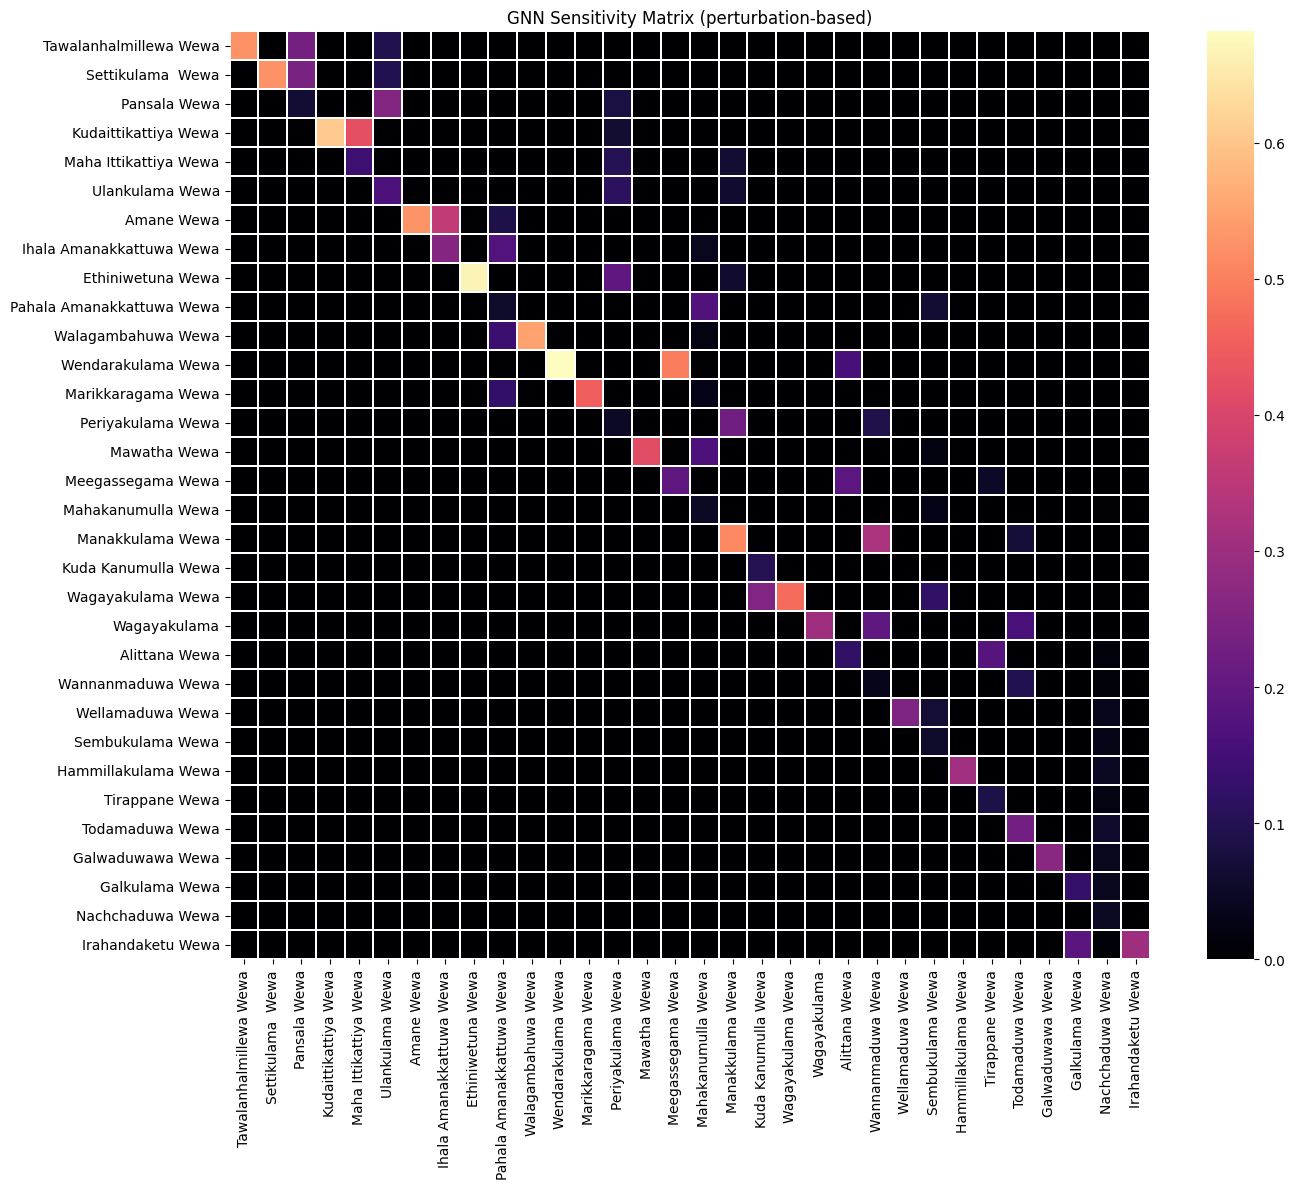

Saved C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\outputs\gnn_sensitivity_matrix.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

# Perturbation-based GNN sensitivity matrix
with torch.no_grad():
    base_emb = model(pyg_data.x, pyg_data.edge_index).numpy()

perturb_sensitivity = np.zeros((32, 32))
for i in range(32):
    x_perturb = pyg_data.x.clone()
    x_perturb[i] += 0.1
    with torch.no_grad():
        new_emb = model(x_perturb, pyg_data.edge_index).numpy()
    perturb_sensitivity[i] = np.linalg.norm(new_emb - base_emb, axis=1)

df_perturb_sens = pd.DataFrame(perturb_sensitivity,
    index=node_list, columns=node_list)

plt.figure(figsize=(14, 12))
sns.heatmap(df_perturb_sens, cmap="magma",
    linewidths=0.2, xticklabels=True, yticklabels=True)
plt.title("GNN Sensitivity Matrix (perturbation-based)")
plt.tight_layout()
plt.savefig(output_dir / "gnn_sensitivity_matrix.png", dpi=150)
plt.show()
print(f"Saved {output_dir / 'gnn_sensitivity_matrix.png'}")


In [3]:
# Export GNN Influence to influence.csv
# Uses perturb_sensitivity  the EXACT same values shown on the influence map
import networkx as nx
from pathlib import Path

output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

records = []

for src in G.nodes():
    for tgt in G.nodes():
        if src == tgt:
            continue

        si = node_idx[src]
        ti = node_idx[tgt]

        # Same value used in the influence map edge titles
        influence_val = float(perturb_sensitivity[si][ti])

        # Only write pairs where GNN detected any influence
        if influence_val > 0:

            # Classify connection type using the graph
            if G.has_edge(src, tgt):
                connection_type = "direct"
                hops = 1
                path_str = f"{src}  {tgt}"
            elif nx.has_path(G, src, tgt):
                paths = list(nx.all_simple_paths(G, src, tgt, cutoff=15))
                if paths:
                    best = min(paths, key=len)   # shortest path
                    hops = len(best) - 1
                    path_str = "  ".join(best)
                else:
                    hops = 0
                    path_str = ""
                connection_type = "indirect"
            else:
                # GNN detected influence even without a flow path
                # This is a non-trivial finding  tanks share structural similarity
                connection_type = "no_flow_path"
                hops = 0
                path_str = "none"

            records.append({
                "from_tank":           src,
                "to_tank":             tgt,
                "gnn_influence_value": round(influence_val, 6),
                "connection_type":     connection_type,
                "hops":                hops,
                "flow_path":           path_str,
            })

df_influence = pd.DataFrame(records)

# Sort strongest influence first
df_influence = df_influence.sort_values(
    "gnn_influence_value", ascending=False
).reset_index(drop=True)
df_influence.insert(0, "rank", range(1, len(df_influence) + 1))

# Save
df_influence.to_csv(output_dir / "influence.csv", index=False)

print("Saved influence.csv " + str(output_dir / "influence.csv"))
print(f"Total pairs with influence: {len(df_influence)}")
print()
print("Top 15 strongest GNN influences:")
print(df_influence[[
    "rank", "from_tank", "to_tank",
    "gnn_influence_value", "connection_type", "hops"
]].head(15).to_string(index=False))


Saved influence.csv C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\outputs\influence.csv
Total pairs with influence: 55

Top 15 strongest GNN influences:
 rank                from_tank                   to_tank  gnn_influence_value connection_type  hops
    1       Wendarakulama Wewa         Meegassegama Wewa             0.497242          direct     1
    2     Kudaittikattiya Wewa     Maha Ittikattiya Wewa             0.422929          direct     1
    3               Amane Wewa  Ihala Amanakkattuwa Wewa             0.358455          direct     1
    4         Manakkulama Wewa         Wannanmaduwa Wewa             0.320402          direct     1
    5             Pansala Wewa           Ulankulama Wewa             0.254257          direct     1
    6        Wagayakulama Wewa       Kuda Kanumulla Wewa             0.252448          direct     1
    7        Settikulama  Wewa              Pansala Wewa             0.237606          direct     1
    8   Tawalanhalmillewa Wewa     

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path

output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

#
# Water Transfer Coefficient ()  calibrated to measured Sri Lankan
# conveyance-loss literature, not an arbitrary fitted window.
#
# Basis:
#  - Conveyance efficiency decays exponentially with channel length
#    (Sur et al., Bhaini Distributary, Punjab  24.2% overall loss).
#  - Velocity  slope (Chezy/Manning open-channel flow), so a channel's
#    *effective exposure length* = path_length / slope, not raw distance.
#  - Reported Sri Lankan / South Asian conveyance losses range ~1233%
#    (tritium-tracer Kala Oya canal: 12%; classic estimate: 1520%;
#    Bhaini Distributary: 24.2%; Maduru Oya/Hurulu Wewa/Minipe 2022-23
#    study: 26.533.1%). k is calibrated so the DATASET AVERAGE efficiency
#    lands at 0.75 (25% average loss  the midpoint of this range).
#

df_alpha = df_edges.copy()

# Effective exposure length: longer + flatter channels expose water to
# seepage longer; steeper channels move water through faster
df_alpha["effective_length_m"] = (
    df_alpha["stream_path_length_m"] / np.sqrt(df_alpha["slope_m/m"])
)

TARGET_AVG_EFFICIENCY = 0.75   # 25% avg loss, midpoint of the 12-33% SL literature range
K = -np.log(TARGET_AVG_EFFICIENCY) / df_alpha["effective_length_m"].mean()

df_alpha["alpha_raw"] = np.exp(-K * df_alpha["effective_length_m"])

print(f"Calibrated decay constant K: {K:.3e}")
print(f"Resulting alpha_raw range: {df_alpha['alpha_raw'].min():.3f} to {df_alpha['alpha_raw'].max():.3f}")
print(f"Resulting alpha_raw mean:  {df_alpha['alpha_raw'].mean():.3f} (target was {TARGET_AVG_EFFICIENCY})")

# Enforce: sum of outgoing fractions per source tank <= 1
group_totals = df_alpha.groupby("source_tank")["alpha_raw"].transform("sum")
df_alpha["alpha_final"] = np.where(
    group_totals > 1.0,
    df_alpha["alpha_raw"] * (0.98 / group_totals),
    df_alpha["alpha_raw"]
)

# Save as edge list
df_alpha_export = df_alpha[[
    "source_tank", "target_tank", "stream_path_length_m", "slope_m/m",
    "effective_length_m", "alpha_final"
]].rename(columns={
    "source_tank": "from_tank",
    "target_tank": "to_tank",
    "alpha_final": "alpha_water_transfer_coefficient"
})
df_alpha_export.to_csv(output_dir / "alpha_edges.csv", index=False)

# Build the NN matrix
tanks = list(G.nodes())
alpha_matrix = pd.DataFrame(0.0, index=tanks, columns=tanks)
for _, row in df_alpha.iterrows():
    alpha_matrix.loc[row["target_tank"], row["source_tank"]] = row["alpha_final"]
alpha_matrix.to_csv(output_dir / "alpha_matrix.csv")

print(f"Saved alpha_edges.csv and alpha_matrix.csv ({len(tanks)}x{len(tanks)}) to {output_dir}")


Calibrated decay constant K: 2.175e-06
Resulting alpha_raw range: 0.215 to 0.975
Resulting alpha_raw mean:  0.790 (target was 0.75)
Saved alpha_edges.csv and alpha_matrix.csv (32x32) to C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\outputs


In [5]:
# ════════════════════════════════════════════════════════════════
# Water Transfer Coefficient (α) — v2: hybrid physically-informed model
# alpha_final_v2 = alpha_hydraulic * C_condition * C_abstraction, normalized
#
# Builds on Stage 1 above (alpha_raw / effective_length_m) — that cell is
# left untouched. This cell adds:
#   Stage 2: tank structural condition correction   (node-level: tank_cond)
#   Stage 3: command-area abstraction correction     (node-level: command_area)
#   Stage 4: outgoing-flow normalization (same 0.98 cap as v1)
#
# Deliberately excluded (per Group 3 / Section 7 of the methodology):
# catchment_area, num_catchment_basins, farmers, tank capacity, soil type.
# These affect inflow/demand, not transfer efficiency, so they stay out of α.
# ════════════════════════════════════════════════════════════════

df_alpha_v2 = df_alpha.copy()  # reuse alpha_raw + effective_length_m from Stage 1

# ── Pull SOURCE-tank node attributes (set in Phase 1's G.add_node call) ──
tank_cond_map    = nx.get_node_attributes(G, "tank_cond")
command_area_map = nx.get_node_attributes(G, "command_area")

df_alpha_v2["source_tank_cond"]    = df_alpha_v2["source_tank"].map(tank_cond_map)
df_alpha_v2["source_command_area"] = df_alpha_v2["source_tank"].map(command_area_map)

print("Unique tank_cond values found:", sorted(df_alpha_v2["source_tank_cond"].dropna().unique(), key=str))
print(f"Command area range: {df_alpha_v2['source_command_area'].min()} to {df_alpha_v2['source_command_area'].max()}")

# ── Stage 2: Tank condition correction (C_condition) ──────────────
# CONFIRMED (data dictionary, Sri Lankan irrigation asset convention):
#   TANK COND = 1 -> Good condition     (low structural leakage)
#   TANK COND = 2 -> Moderate/Fair       (normal losses)
#   TANK COND = 3 -> Poor condition      (higher seepage/leakage)
# Two tanks have "-" (missing) -> treated as neutral (no penalty, factor 1.00).
# REPAIRS 10 Y is a separate column and is NOT used here, per instruction.
CONDITION_FACTOR = {1: 1.00, 2: 0.90, 3: 0.80}

def map_condition(val):
    try:
        code = int(val)
    except (TypeError, ValueError):
        return 1.00  # missing ("-") -> neutral, no penalty applied
    return CONDITION_FACTOR.get(code, 1.00)

df_alpha_v2["C_condition"] = df_alpha_v2["source_tank_cond"].apply(map_condition)

# ── Stage 3: Command-area abstraction correction (C_abstraction) ──
BETA = 0.25  # max command area reduces transferable water by ~25%
CA_max = df_alpha_v2["source_command_area"].max()
df_alpha_v2["C_abstraction"] = 1 - BETA * (
    df_alpha_v2["source_command_area"].fillna(0) / CA_max
)

# ── Combine: alpha_hydraulic (alpha_raw) × C_condition × C_abstraction ──
df_alpha_v2["alpha_combined"] = (
    df_alpha_v2["alpha_raw"] * df_alpha_v2["C_condition"] * df_alpha_v2["C_abstraction"]
)

# ── Stage 4: Outgoing-flow normalization (per source tank, same 0.98 cap as v1) ──
group_totals_v2 = df_alpha_v2.groupby("source_tank")["alpha_combined"].transform("sum")
df_alpha_v2["alpha_final_v2"] = np.where(
    group_totals_v2 > 1.0,
    df_alpha_v2["alpha_combined"] * (0.98 / group_totals_v2),
    df_alpha_v2["alpha_combined"]
)

print(f"\nalpha_final_v2 range: {df_alpha_v2['alpha_final_v2'].min():.3f} to {df_alpha_v2['alpha_final_v2'].max():.3f}")
print(f"alpha_final_v2 mean:  {df_alpha_v2['alpha_final_v2'].mean():.3f}")

# ── Save as SEPARATE edge list / matrix — v1 files untouched ──────
df_alpha_v2_export = df_alpha_v2[[
    "source_tank", "target_tank", "stream_path_length_m", "slope_m/m",
    "effective_length_m", "alpha_raw", "C_condition", "C_abstraction", "alpha_final_v2"
]].rename(columns={
    "source_tank": "from_tank",
    "target_tank": "to_tank",
    "alpha_final_v2": "alpha_water_transfer_coefficient_v2"
})
df_alpha_v2_export.to_csv(output_dir / "alpha_edges_v2.csv", index=False)

alpha_matrix_v2 = pd.DataFrame(0.0, index=tanks, columns=tanks)
for _, row in df_alpha_v2.iterrows():
    alpha_matrix_v2.loc[row["target_tank"], row["source_tank"]] = row["alpha_final_v2"]
alpha_matrix_v2.to_csv(output_dir / "alpha_matrix_v2.csv")

print(f"\nSaved alpha_edges_v2.csv and alpha_matrix_v2.csv to {output_dir}")

Unique tank_cond values found: ['-', 1, 2, 3]
Command area range: 20.0 to 180.0

alpha_final_v2 range: 0.192 to 0.975
alpha_final_v2 mean:  0.668

Saved alpha_edges_v2.csv and alpha_matrix_v2.csv to C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\outputs


In [6]:
from pyvis.network import Network
import matplotlib.cm as cm
import matplotlib.colors as mcolors

net2 = Network(height="950px", width="100%", directed=True, bgcolor="#f9f9f7")
# NOTE: no `heading=` here — we build our own title block below to avoid pyvis's duplicate-heading bug

final_score_map = df_rank.set_index("tank")["final_score"]

# ── Data-driven stability threshold, not a guessed constant ──
# Flag the top 25% most-variable-ranking tanks as "unstable" — a defensible,
# distribution-based cutoff instead of an arbitrary absolute number
STABILITY_THRESHOLD = stability_std.quantile(0.75)
unstable_tanks = set(stability_std[stability_std > STABILITY_THRESHOLD].index)
print(f"Stability std range: {stability_std.min():.2f} to {stability_std.max():.2f}")
print(f"Threshold (75th percentile): {STABILITY_THRESHOLD:.2f}")
print(f"Flagged as unstable: {len(unstable_tanks)} of {len(stability_std)} tanks")

for node in G.nodes():
    sc = final_score_map.get(node, 0)
    rank_val = df_rank[df_rank.tank == node]["final_rank"].values
    rank_str = f"Rank #{rank_val[0]}" if len(rank_val) else ""
    color = "#E24B4A" if sc > 0.6 else ("#EF9F27" if sc > 0.35 else "#1D9E75")
    is_unstable = node in unstable_tanks
    stability_note = f"UNSTABLE (std={stability_std.get(node, 0):.2f})" if is_unstable else "stable"

    net2.add_node(
        node, label=node, size=10 + sc * 45,
        color=color,
        shape="diamond" if is_unstable else "dot",
        borderWidth=3 if is_unstable else 1,
        font={"size": 14, "background": "rgba(255,255,255,0.75)"},   # legible over crossing edges
        title=f"{rank_str} | Final Score: {sc:.3f}\nRank stability: {stability_note}"   # \n not <br>
    )

influence_vals = [perturb_sensitivity[node_idx[s]][node_idx[t]] for s, t in G.edges()]
norm = mcolors.Normalize(vmin=min(influence_vals), vmax=max(influence_vals))
cmap = cm.get_cmap("plasma")

for src, tgt, d in G.edges(data=True):
    si, ti = node_idx[src], node_idx[tgt]
    influence = perturb_sensitivity[si][ti]
    alpha_val = alpha_matrix.loc[tgt, src] if (tgt in alpha_matrix.index and src in alpha_matrix.columns) else None
    connection_type = d.get("connection_type", "direct")

    edge_color = mcolors.to_hex(cmap(norm(influence)))
    width = max(1, (alpha_val or 0.3) * 12)

    tooltip = f"GNN influence: {influence:.4f}\n"
    tooltip += f"alpha (water transfer): {alpha_val:.3f}\n" if alpha_val is not None else "alpha: n/a (indirect edge)\n"
    tooltip += f"Type: {connection_type}"

    net2.add_edge(src, tgt, width=width, color=edge_color, title=tooltip,
                  dashes=(connection_type != "direct"))

# Much more generous spacing to reduce label/edge overlap at 32 nodes
net2.set_options("""{
  "layout": {
    "hierarchical": {
      "enabled": true, "direction": "UD", "sortMethod": "directed",
      "levelSeparation": 180, "nodeSpacing": 220, "treeSpacing": 260
    }
  },
  "physics": { "enabled": false },
  "edges": { "smooth": { "type": "cubicBezier", "forceDirection": "vertical" } }
}""")

net2.save_graph(str(output_dir / "cascade_influence_map_final.html"))

# ── Title + legend, placed BELOW the graph rather than floating on top of it ──
header_html = """
<div style="font-family:sans-serif; padding:16px 20px 4px 20px;">
  <h1 style="margin:0; font-size:26px;">Cascade Tank Network - Combined Influence and Physical Conveyance Map</h1>
</div>
"""

legend_html = """
<div style="font-family:sans-serif; font-size:13px; line-height:1.6;
            padding:14px 20px; border-top:1px solid #ccc; background:white;">
  <b>Legend</b><br>
  <b>Node colour</b> - Final importance score: High (&gt;0.6) | Medium (0.35-0.6) | Low (&lt;0.35) &nbsp;&nbsp;
  <b>Node shape</b> - Diamond = unstable ranking (top 25% by seed variance) | Circle = stable &nbsp;&nbsp;
  <b>Edge width</b> - alpha (physical water-transfer fraction) &nbsp;&nbsp;
  <b>Edge colour</b> - GNN influence (perturbation sensitivity), dark purple (low) to yellow (high) &nbsp;&nbsp;
  <b>Edge style</b> - Solid = direct channel, dashed = indirect/derived path
</div>
"""

html_file = output_dir / "cascade_influence_map_final.html"
with open(html_file, "r", encoding="utf-8", errors="replace") as f:
    html = f.read()

if "<meta charset=" not in html:
    html = html.replace("<head>", '<head>\n<meta charset="utf-8">')

html = html.replace("<body>", "<body>" + header_html)
html = html.replace("</body>", legend_html + "</body>")

with open(html_file, "w", encoding="utf-8") as f:
    f.write(html)

print("Saved combined influence + conveyance map.")

Stability std range: 1.46 to 10.99
Threshold (75th percentile): 9.15
Flagged as unstable: 8 of 32 tanks
Saved combined influence + conveyance map.


C:\Users\dinit\AppData\Local\Temp\ipykernel_12252\3691077835.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


In [7]:
import folium
from folium.plugins import AntPath, MiniMap, Fullscreen
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ── Center the map on the tank network's actual location ──
lats = [G.nodes[n]["lat"] for n in G.nodes()]
lons = [G.nodes[n]["lon"] for n in G.nodes()]
center = [sum(lats)/len(lats), sum(lons)/len(lons)]

m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")
Fullscreen(position="topright").add_to(m)
MiniMap(toggle_display=True).add_to(m)

# Satellite base layer — lets you visually confirm tanks OSM hasn't traced yet
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community",
    name="Satellite imagery (Esri)",
    overlay=False,   # base layer — mutually exclusive with CartoDB positron
    control=True
).add_to(m)

final_score_map = df_rank.set_index("tank")["final_score"]
STABILITY_THRESHOLD = stability_std.quantile(0.75)
unstable_tanks = set(stability_std[stability_std > STABILITY_THRESHOLD].index)

influence_vals = [perturb_sensitivity[node_idx[s]][node_idx[t]] for s, t in G.edges()]
norm = mcolors.Normalize(vmin=min(influence_vals), vmax=max(influence_vals))
cmap = cm.get_cmap("plasma")

# ── Edges first, so markers render on top of the lines ──
for src, tgt, d in G.edges(data=True):
    si, ti = node_idx[src], node_idx[tgt]
    influence = perturb_sensitivity[si][ti]
    alpha_val = alpha_matrix.loc[tgt, src] if (tgt in alpha_matrix.index and src in alpha_matrix.columns) else None
    connection_type = d.get("connection_type", "direct")

    edge_color = mcolors.to_hex(cmap(norm(influence)))
    weight = max(1.5, (alpha_val or 0.3) * 10)

    src_coord = [G.nodes[src]["lat"], G.nodes[src]["lon"]]
    tgt_coord = [G.nodes[tgt]["lat"], G.nodes[tgt]["lon"]]

    popup_text = (f"<b>{src} &rarr; {tgt}</b><br>"
                  f"GNN influence: {influence:.4f}<br>"
                  f"alpha (water transfer): {alpha_val:.3f}" if alpha_val is not None else "alpha: n/a (indirect)")
    popup_text += f"<br>Type: {connection_type}"

    if connection_type == "direct":
        AntPath(
            locations=[src_coord, tgt_coord],
            color=edge_color, weight=weight, opacity=0.85,
            delay=1000, dash_array=[10, 20],
            popup=folium.Popup(popup_text, max_width=250)
        ).add_to(m)
    else:
        folium.PolyLine(
            locations=[src_coord, tgt_coord],
            color=edge_color, weight=weight, opacity=0.5, dash_array="4,8",
            popup=folium.Popup(popup_text, max_width=250)
        ).add_to(m)

# ── Nodes on top ──
for node in G.nodes():
    sc = final_score_map.get(node, 0)
    rank_val = df_rank[df_rank.tank == node]["final_rank"].values
    rank_str = f"Rank #{rank_val[0]}" if len(rank_val) else ""
    fill_color = "#E24B4A" if sc > 0.6 else ("#EF9F27" if sc > 0.35 else "#1D9E75")
    is_unstable = node in unstable_tanks
    stability_note = f"UNSTABLE (std={stability_std.get(node, 0):.2f})" if is_unstable else "stable"

    popup_html = (f"<b>{node}</b><br>{rank_str}<br>"
                  f"Final score: {sc:.3f}<br>Rank stability: {stability_note}")

    folium.CircleMarker(
        location=[G.nodes[node]["lat"], G.nodes[node]["lon"]],
        radius=6 + sc * 14,
        color="#111111" if is_unstable else "#666666",
        weight=3 if is_unstable else 1,
        fill=True, fill_color=fill_color, fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=220),
        tooltip=node
    ).add_to(m)

# ── NSDI official Pond layer, as toggleable overlay for coordinate verification ──
folium.raster_layers.WmsTileLayer(
    url="https://gisapps.nsdi.gov.lk/server/services/SLNSDI/Inland_Waters/MapServer/WmsServer",
    layers="11", 
    # "Pond"
    name="NSDI - Pond (official)",
    fmt="image/png",
    transparent=True,
    version="1.3.0",
    attr="Sri Lanka NSDI - Survey Department",
    overlay=True,
    control=True
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# ── Title ──
title_html = """
<div style="position:fixed; top:10px; left:60px; z-index:1000;
            background:white; padding:8px 16px; border-radius:6px;
            border:1px solid #ccc; font-family:sans-serif;">
  <h3 style="margin:0;">Cascade Tank Network - Geographic Flow Map</h3>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# ── Legend ──
legend_html = """
<div style="position:fixed; bottom:20px; left:20px; z-index:1000;
            background:white; padding:12px 16px; border-radius:6px;
            border:1px solid #ccc; font-family:sans-serif; font-size:12px; line-height:1.6; max-width:300px;">
  <b>Legend</b><br>
  <b>Marker fill</b> - Final importance score: 
  <span style="color:#E24B4A;">High</span> |
  <span style="color:#EF9F27;">Medium</span> |
  <span style="color:#1D9E75;">Low</span><br>
  <b>Marker ring</b> - Thick dark = unstable rank (top 25% seed variance), thin grey = stable<br>
  <b>Line colour</b> - GNN influence, dark purple (low) to yellow (high)<br>
  <b>Line width</b> - alpha (physical water-transfer fraction)<br>
  <b>Animated dashes</b> - Direction of water flow, direct channels only<br>
  <b>Static dashed line</b> - Indirect/derived path (not a physical channel)<br>
  <b>Base layer toggle</b> - Switch to Satellite to confirm tanks not traced in OSM<br>
  <b>Overlay toggle</b> - NSDI official Pond layer for coordinate verification
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save(str(output_dir / "cascade_geographic_flow_map.html"))
print(f"Saved geographic flow map to {output_dir / 'cascade_geographic_flow_map.html'}")

Saved geographic flow map to C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\outputs\cascade_geographic_flow_map.html


C:\Users\dinit\AppData\Local\Temp\ipykernel_12252\3927994694.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")
